# Chapter 13 — Emitting the kernel: invariant encoders

*Companion notebook to **The Learned Kernel**, Ch. 13. Run top to bottom.*

Chapter 12 built an emitter gθ: context → measure m and measured its regret, leaving one question:
**what map** gθ, and how does it stay faithful to the symmetry tabular data demands? Attention has
two jobs. As **predictive geometry** (softmax(QKᵀ) combining labels) it is asymmetric and
order-creating — wrong for exchangeable rows (Ch. 11). As an **invariant encoder** — a
permutation-invariant map from a context set to kernel parameters — it is exactly right. A
**symmetry bottleneck** separates the two: because the encoder emits a measure and the prediction
is the symmetric PSD kernel K_m, the encoder's internal asymmetry **cannot leak** into the geometry.

**The division of labor.** The encoder's job is **invariance**; **prediction is the spectral
kernel's job** (symmetric PSD + KRR, Ch. 8). This notebook verifies the invariances, then
demonstrates the bottleneck.

## Setup (GPU recommended)

In [1]:
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from lkbook import set_style
from lkbook.chapters import ch13

set_style()
device = ch13._device()
print("device:", device)

device: cuda


## 13.1  The symmetry bottleneck

The encoder reads the context with any internal machinery (even asymmetric attention) and emits a
measure m; the prediction is the symmetric PSD kernel K_m. The encoder's job is **invariance**, the
kernel's job is **prediction**, and the measure is the waist between them: the encoder's asymmetry
stops at m.

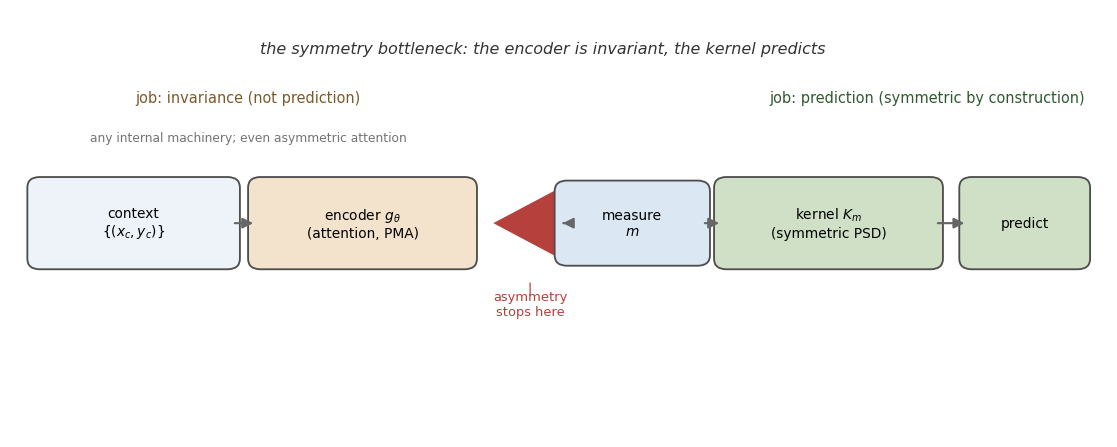

In [3]:
ch13.make_bottleneck_figure()
plt.show()

## 13.2  The encoder's job: invariance (verified)

Train a **feature-token** emitter (cell embedding → feature-axis attention → row-axis PMA per
feature → shared per-feature heads), then verify on a held-out task:
- **row permutation** — shuffle the context rows; the prediction is unchanged;
- **padded-column content** — overwrite the masked columns with noise; the prediction is unchanged
  (so padding a width-d table to d_max is sound);
- **width** — one checkpoint serves several feature counts, beating predict-the-mean at each.

Column-*order* invariance is **not** among these: the dense interaction warp W couples features in
a fixed order, so permuting active columns changes the kernel — a stated limitation (a
feature-symmetric W would be required).

In [4]:
ft = ch13.train_feature_token(steps=3000, B=32, device=device, seed=0)
inv = ch13.invariance_checks(ft, device=device)
print(f"row-permutation  max |Δpred| = {inv['row_perm']:.2e}")
print(f"padded-content   max |Δpred| = {inv['pad_content']:.2e}   (exact)")
w = ch13.width_check(ft, device=device)
print("one checkpoint, widths d=3/5/8  (emitter MSE / predict-mean MSE):",
      {da: round(w[da]['ratio'], 3) for da in w})

row-permutation  max |Δpred| = 2.46e-04
padded-content   max |Δpred| = 0.00e+00   (exact)


one checkpoint, widths d=3/5/8  (emitter MSE / predict-mean MSE): {3: 0.585, 5: 0.713, 8: 0.825}


## 13.3  The bottleneck, measured: encoder attention symmetry is immaterial

Train two emitters that differ **only** in whether the encoder's attention is **symmetric**
(Mahalanobis, shared projection → score zᵢᵀMzⱼ, M=AᵀA) or **asymmetric** (separate W_Q≠W_K), and
compare regret over Bayes. If the encoder's asymmetry mattered to the prediction, they would
differ. They don't — the prediction is symmetric by construction (the bottleneck). This is the
**mirror image of Ch. 11**: asymmetry is fatal in the *predictor* (forfeits KRR), harmless in the
*encoder*.

In [5]:
sa = ch13.run_sym_asym_ab(steps=3000, n_tasks=400, device=device)
print("  k    symmetric   asymmetric   gap")
for k in sa["ks"]:
    print(f"{k:>4}    {sa['symmetric'][k]['regret']:.3f}      {sa['asymmetric'][k]['regret']:.3f}"
          f"      {sa['gap'][k]:+.3f}")

  k    symmetric   asymmetric   gap
   8    0.028      0.025      -0.003
  32    0.092      0.085      -0.007
  64    0.118      0.114      -0.004
 128    0.150      0.139      -0.011
 256    0.160      0.145      -0.015
 512    0.153      0.141      -0.011


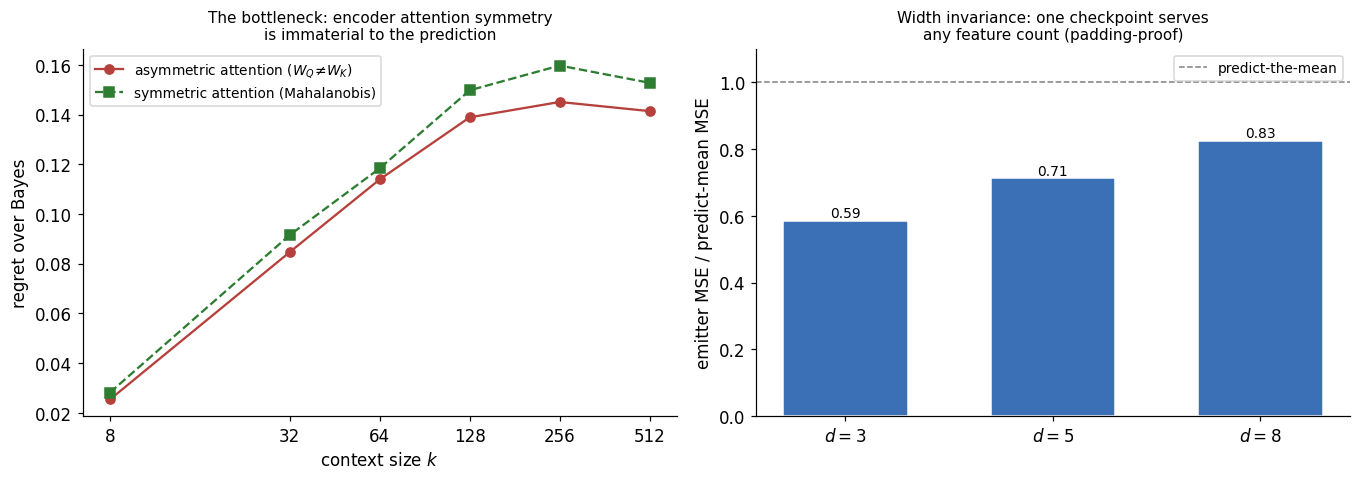

In [6]:
ch13.make_encoder_figure(sa, w)
plt.show()

The two curves nearly coincide — the encoder's attention symmetry barely moves the regret, a
fraction of any difference you would care about. The bottleneck neutralizes it: use whatever
encoder infers the measure best (asymmetric attention is fine, even a hair better), and let the
kernel predict symmetrically.

**A note on pooling.** Mean pooling and attention pooling (PMA) are *both* permutation-invariant;
the choice is about inference quality, not invariance, and at this scale the masked mean is
competitive with and more stable than PMA across seeds (the in-context literature reports a PMA
advantage at larger scale). The invariance — not the pool — is the chapter's point.

## Explorer — verify an invariance yourself

In [7]:
from ipywidgets import interact, IntSlider


def check_rows(k=128):
    """Permute the context rows and report the maximum change in the prediction (should be ~0)."""
    inv = ch13.invariance_checks(ft, k=k, device=device)
    fig, ax = plt.subplots(figsize=(5.4, 3.6), constrained_layout=True)
    ax.bar([0, 1], [inv["row_perm"], inv["pad_content"]], width=0.6,
           color=["#3b6fb6", "#2e7d32"], edgecolor="white")
    ax.set_yscale("log")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["row permutation", "padded content"])
    ax.set_ylabel("max |Δ prediction|  (log)")
    ax.set_title(f"k={k}: invariances hold to tolerance")
    ax.axhline(1e-3, color="0.6", ls="--", lw=0.8)
    plt.show()


interact(check_rows, k=IntSlider(min=32, max=256, step=32, value=128, description="k"))

interactive(children=(IntSlider(value=128, description='k', max=256, min=32, step=32), Output()), _dom_classes…

<function __main__.check_rows(k=128)>

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm mean pooling and attention pooling are both permutation-invariant by training
each and checking both produce finite regret and beat predict-the-mean.

In [8]:
# TODO: train ch13.train_emitter(pool="mean") and pool="pma"; eval_regret_vs_k; print emitter vs mean.

<details><summary>Solution</summary>

```python
for pool in ("mean", "pma"):
    net = ch13.train_emitter(steps=1500, pool=pool, device=device, seed=0)
    r = ch13.eval_regret_vs_k(net, 8, 4, 3, ks=(128,), n_tasks=200, device=device)[128]
    print(pool, "emitter", round(r["emitter"], 3), "mean", round(r["mean"], 3))
```
Both are invariant by their pooling; mean is the uniform-attention special case of PMA.
</details>

**(medium)** Show the padded-column invariance is *exact*: overwrite the masked columns with
different magnitudes of noise and confirm the prediction never changes.

In [9]:
# TODO: call ch13.invariance_checks at a few seeds; confirm pad_content is ~0 each time.

<details><summary>Solution</summary>

```python
for s in range(4):
    print(ch13.invariance_checks(ft, seed=s, device=device)["pad_content"])
```
The feature mask zeroes the padded columns in the cell embedding, the feature attention and the
Gram, so their content enters nowhere — the change is 0 to floating-point.
</details>

**(⋆)** Column-*order* invariance is the one that fails. Permute the active feature columns of a
task and show the prediction *does* change — then explain why (the dense interaction warp W).

<details><summary>Solution</summary>

The kernel warps the feature-concatenated embedding by a fixed dense W, φ = Wψ, which couples the
features in a fixed order. Permuting the active columns permutes the blocks of ψ but not W, so Wψ —
and the distance ‖φ(x)−φ(x′)‖ — changes. Column-order invariance would require a feature-symmetric
warp; row-permutation, padded-content and width invariance are what this encoder delivers.
</details>